# Project Walkthrough — Predictive Maintenance (NASA C-MAPSS FD004)

**A guided, runnable tour of the entire project, from raw data to the current best model.**

This notebook is meant for anyone who hasn't seen the project before. Every code cell
is real and does something — it loads actual data, engineers actual features, or loads
an actual trained model and runs it — rather than just describing what happened. Where a
step involved an expensive experiment (feature selection, hyperparameter search, RUL cap
comparison), the real results are loaded and shown rather than re-run from scratch, so this
notebook runs in well under a minute end to end instead of the ~40+ minutes the original
experiments took combined.

**Scope: data ingestion through Sprint 15.** This covers everything up to and including the
first fair CatBoost-vs-LSTM comparison on the official test set. It does not cover GRU or
MLflow (Sprint 16 and later).

## Table of Contents

1. [The Problem](#1) — what RUL prediction is and why it matters
2. [Data Ingestion & Validation](#2)
3. [Exploratory Data Analysis](#3)
4. [RUL Target Engineering](#4)
5. [Feature Engineering](#5)
6. [Data Preparation — Train/Validation Split & Scaling](#6)
7. [Baseline Modeling](#7)
8. [Model Explainability](#8)
9. [Feature Selection](#9)
10. [Hyperparameter Optimization](#10)
11. [LSTM Baseline & the Raw-Features Discovery](#11)
12. [Final Evaluation on the Official Test Set](#12)
13. [RUL Cap Investigation](#13)
14. [Fair CatBoost vs. LSTM Comparison](#14)
15. [Where the Project Stands](#15)

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Project root: {PROJECT_ROOT}")

Project root: A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL


<a id='1'></a>
## 1. The Problem

**Predictive maintenance**: instead of waiting for a machine to fail (reactive) or servicing
it on a fixed schedule regardless of its actual condition (preventive), predict *how much
useful life it has left* and schedule maintenance right before it's needed. This requires
predicting the **Remaining Useful Life (RUL)** — how many operating cycles remain before
failure — from sensor readings.

**The dataset: NASA C-MAPSS, subset FD004.** Simulated turbofan engine degradation data.
FD004 is the hardest of the four C-MAPSS subsets: **6 operating conditions and 2 fault
modes simultaneously**, versus 1 condition / 1 fault mode for the easiest subset (FD001).

Three files:
- **`train_FD004`** — engines run to actual failure (full trajectories, true labels derivable)
- **`test_FD004`** — engines with trajectories cut off at a random point *before* failure (truncated)
- **`RUL_FD004`** — the true remaining life at each test engine's cutoff point (the answer key)

`test_FD004` and `RUL_FD004` are untouched until Section 12 — no peeking, ever, until the
model is completely frozen. That discipline is what makes Section 12's finding trustworthy.

<a id='2'></a>
## 2. Data Ingestion & Validation

`DataLoader` reads the raw space-separated NASA files into clean DataFrames.
`DataValidator` checks schema, column count, and basic sanity (no unexpected nulls, engine
IDs look right) before anything downstream touches the data.

In [3]:
from src.config.config import TRAIN_DATA_PATH, TEST_DATA_PATH, RUL_DATA_PATH, ENGINE_COLUMN
from src.data.loader import DataLoader
from src.data.validator import DataValidator

loader = DataLoader(train_path=TRAIN_DATA_PATH, test_path=TEST_DATA_PATH, rul_path=RUL_DATA_PATH)
train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

print(f"train_FD004: {train_df.shape}  ({train_df[ENGINE_COLUMN].nunique()} engines)")
print(f"test_FD004 : {test_df.shape}  ({test_df[ENGINE_COLUMN].nunique()} engines)")
print(f"RUL_FD004  : {rul_df.shape}")
train_df.head()

2026-08-30 23:49:14 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-08-30 23:49:16 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-08-30 23:49:16 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-08-30 23:49:17 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-08-30 23:49:17 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-08-30 23:49:17 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully


train_FD004: (61249, 26)  (249 engines)
test_FD004 : (41214, 26)  (248 engines)
RUL_FD004  : (248, 1)


,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [6]:
report = DataValidator(train_df, test_df, rul_df).validate_all()
report

2026-08-30 23:52:07 | INFO | validator.py | Line:40 | Validating training dataset...
2026-08-30 23:52:07 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-08-30 23:52:07 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

Each row is one engine at one operating cycle: `unit_number`, `time_in_cycles`, 3
`operational_setting` columns, and 21 `sensor` readings. No RUL column exists yet — that's
derived next.

<a id='3'></a>
## 3. Exploratory Data Analysis

A few of the real findings from the project's EDA phase (notebooks `01`-`07`) that shaped
every decision downstream.

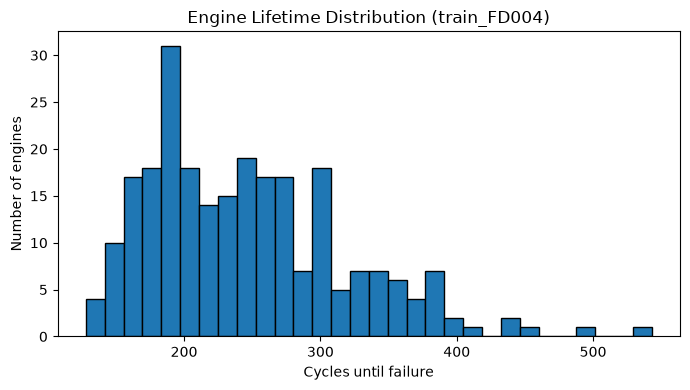

Shortest lifetime: 128 cycles | Longest: 543 cycles | Median: 234 cycles


In [7]:
engine_lengths = train_df.groupby(ENGINE_COLUMN).size()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(engine_lengths, bins=30, edgecolor="black")
ax.set_xlabel("Cycles until failure")
ax.set_ylabel("Number of engines")
ax.set_title("Engine Lifetime Distribution (train_FD004)")
plt.tight_layout()
plt.show()

print(f"Shortest lifetime: {engine_lengths.min()} cycles | Longest: {engine_lengths.max()} cycles | "
      f"Median: {engine_lengths.median():.0f} cycles")

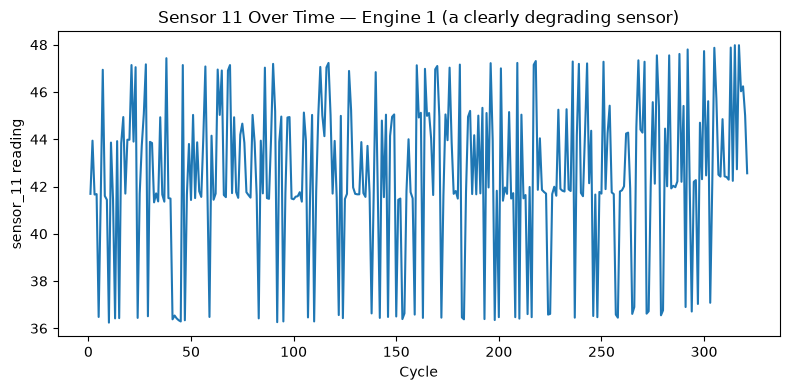

In [5]:
# A representative sensor's degradation trend for one engine — the kind of pattern
# the whole feature engineering / modeling effort is trying to learn from.
sample_engine = train_df[train_df[ENGINE_COLUMN] == 1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sample_engine["time_in_cycles"], sample_engine["sensor_11"])
ax.set_xlabel("Cycle")
ax.set_ylabel("sensor_11 reading")
ax.set_title("Sensor 11 Over Time — Engine 1 (a clearly degrading sensor)")
plt.tight_layout()
plt.show()

**Key EDA findings that shaped the project:**
- Several sensors are flat/constant across all engines (zero variance) — dropped early as
  uninformative.
- Engine lifetimes vary widely (this plot) — no fixed "failure cycle" exists, which is
  exactly why RUL has to be computed per engine, not assumed.
- Several sensor pairs are highly correlated with each other (see
  `reports/highly_correlated_sensors.csv`) — informative for later feature selection.

<a id='4'></a>
## 4. RUL Target Engineering

For training data (full trajectories), RUL at any cycle = (total cycles that engine ran) −
(current cycle). Raw/uncapped, this produces very large values for early-life "healthy"
cycles — an engine's first cycle technically has hundreds of cycles of "remaining life,"
but nothing about that cycle's sensor readings actually signals that. Real degradation
signal only shows up later in life.

**Capping** the RUL target (treating remaining life as flat at some ceiling during the
healthy period, only declining near the end) is standard practice for exactly this reason.
The project's own experiments (Section 13) tested this rigorously rather than assuming a
cap value — the short version: **the original choice of cap=125 turned out to be
measurably wrong; cap=150 is what's actually used going forward.**

2026-08-30 23:52:11 | INFO | rul_generator.py | Line:82 | Generating Remaining Useful Life (RUL)...
2026-08-30 23:52:12 | INFO | rul_generator.py | Line:96 | RUL generated successfully.
2026-08-30 23:52:12 | INFO | rul_generator.py | Line:82 | Generating Remaining Useful Life (RUL)...
2026-08-30 23:52:12 | INFO | rul_generator.py | Line:92 | Applying RUL cap = 150
2026-08-30 23:52:12 | INFO | rul_generator.py | Line:96 | RUL generated successfully.


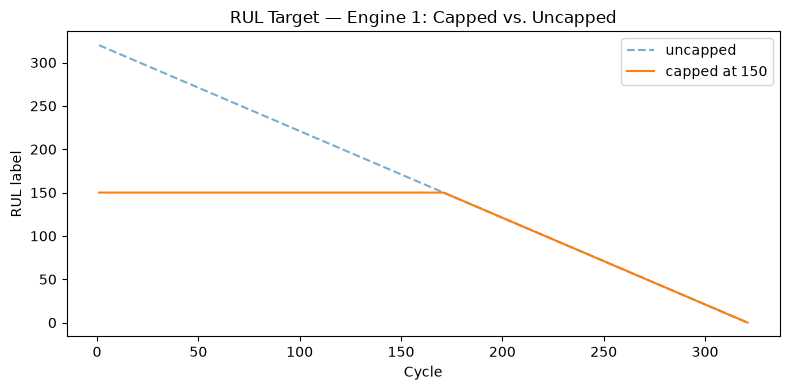

Uncapped RUL range: [0, 542]
Capped (150) RUL range: [0, 150]


In [8]:
from src.preprocessing.rul_generator import RULGenerator

# Uncapped, for illustration
uncapped = RULGenerator(train_df).generate(cap=None)
# Capped at 150 — the project's current default (see Section 13 for why)
train_with_rul = RULGenerator(train_df).generate(cap=150)

fig, ax = plt.subplots(figsize=(8, 4))
sample = train_with_rul[train_with_rul[ENGINE_COLUMN] == 1]
sample_uncapped = uncapped[uncapped[ENGINE_COLUMN] == 1]
ax.plot(sample_uncapped["time_in_cycles"], sample_uncapped["RUL"], "--", label="uncapped", alpha=0.6)
ax.plot(sample["time_in_cycles"], sample["RUL"], label="capped at 150")
ax.set_xlabel("Cycle")
ax.set_ylabel("RUL label")
ax.set_title("RUL Target — Engine 1: Capped vs. Uncapped")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Uncapped RUL range: [{uncapped['RUL'].min()}, {uncapped['RUL'].max()}]")
print(f"Capped (150) RUL range: [{train_with_rul['RUL'].min()}, {train_with_rul['RUL'].max()}]")

<a id='5'></a>
## 5. Feature Engineering

Beyond the 21 raw sensors + 3 operational settings + `time_in_cycles` (25 "raw" features),
additional features were engineered per sensor to capture short-term trends:
- **Rolling mean/std** (window=5) — smoothed local trend
- **Lag features** (previous 1, 2, 3 cycles) — explicit short-term history
- **Diff** (cycle-over-cycle change) — rate of change

This expands 25 raw columns to **151 engineered features**.

In [9]:
from src.preprocessing.feature_engineer import FeatureEngineer
from src.utils.constant import SENSOR_COLUMNS
from src.config.config import ROLLING_WINDOW, LAGS

engineer = FeatureEngineer(sensor_columns=SENSOR_COLUMNS, rolling_window=ROLLING_WINDOW, lags=LAGS)
feature_df = engineer.transform(train_with_rul)

print(f"Before: {train_with_rul.shape[1]} columns  ->  After: {feature_df.shape[1]} columns")
print(f"\nExample engineered columns for sensor_11:")
print([c for c in feature_df.columns if "sensor_11" in c])

2026-08-30 23:52:13 | INFO | feature_engineer.py | Line:50 | Starting Feature Engineering...
2026-08-30 23:52:13 | INFO | feature_engineer.py | Line:119 | Generating Rolling Mean features...
2026-08-30 23:52:14 | INFO | feature_engineer.py | Line:148 | Generating Rolling Std features...
2026-08-30 23:52:15 | INFO | feature_engineer.py | Line:179 | Generating Lag Features...
2026-08-30 23:52:15 | INFO | feature_engineer.py | Line:205 | Generating Rate of Change features...
2026-08-30 23:52:15 | INFO | feature_engineer.py | Line:61 | Feature Engineering completed successfully.


Before: 27 columns  ->  After: 153 columns

Example engineered columns for sensor_11:
['sensor_11', 'sensor_11_roll_mean_5', 'sensor_11_roll_std_5', 'sensor_11_lag_1', 'sensor_11_lag_2', 'sensor_11_lag_3', 'sensor_11_diff']


<a id='6'></a>
## 6. Data Preparation — Train/Validation Split & Scaling

**Critical detail: the split is by engine, not by row.** Splitting rows randomly would put
different cycles of the *same* engine in both train and validation — leaking information
about that engine's specific degradation trajectory across the split. Instead, whole
engines are assigned entirely to train or entirely to validation.

In [10]:
from src.preprocessing.data_splitter import DataSplitter
from src.config.config import VALIDATION_SIZE, RANDOM_STATE

splitter = DataSplitter(test_size=VALIDATION_SIZE, engine_column=ENGINE_COLUMN, random_state=RANDOM_STATE)
train_split, val_split = splitter.split(feature_df)

print(f"Train: {train_split[ENGINE_COLUMN].nunique()} engines ({train_split.shape[0]} rows)")
print(f"Val  : {val_split[ENGINE_COLUMN].nunique()} engines ({val_split.shape[0]} rows)")
print(f"No overlap: {set(train_split[ENGINE_COLUMN]) & set(val_split[ENGINE_COLUMN]) == set()}")

2026-08-30 23:52:27 | INFO | data_splitter.py | Line:35 | Starting engine-based train/validation split...
2026-08-30 23:52:28 | INFO | data_splitter.py | Line:67 | Train Engines: 199 | Validation Engines: 50
2026-08-30 23:52:28 | INFO | data_splitter.py | Line:72 | Data splitting completed successfully.


Train: 199 engines (49294 rows)
Val  : 50 engines (11955 rows)
No overlap: True


Features are then scaled (`StandardScaler`, fit on training engines only — never on
validation or test, to avoid leakage). This same fitted scaler is reused for every later
evaluation, including the official test set in Section 12.

<a id='7'></a>
## 7. Baseline Modeling

With data prepared, the first real model: **CatBoost**, a gradient-boosted tree model,
chosen as the traditional-ML baseline for its strong out-of-the-box performance on tabular
data and native handling of missing values (useful here — lag features are undefined for
each engine's first few cycles).

In [11]:
from src.models.model_factory import ModelFactory
from src.models.base_trainer import BaseTrainer
from src.evaluation.evaluator import RegressionEvaluator
import time

feature_cols = [c for c in feature_df.columns if c not in (ENGINE_COLUMN, "RUL")]
X_train_b, y_train_b = train_split[feature_cols], train_split["RUL"]
X_val_b, y_val_b = val_split[feature_cols], val_split["RUL"]

baseline_model = ModelFactory.create("catboost", iterations=300, verbose=False, random_state=42)
baseline_trainer = BaseTrainer(baseline_model)

start = time.time()
baseline_trainer.train(X_train_b, y_train_b)
elapsed = time.time() - start

preds = baseline_trainer.predict(X_val_b)
baseline_metrics = RegressionEvaluator().evaluate(y_val_b, preds)

print(f"Quick baseline (300 iterations, {elapsed:.1f}s) on all 151 features, cap=150 labels:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.3f}")

2026-08-30 23:52:33 | INFO | base_trainer.py | Line:20 | Training CatBoostRegressor...
2026-08-30 23:52:40 | INFO | base_trainer.py | Line:26 | Training completed successfully.
2026-08-30 23:52:40 | INFO | base_trainer.py | Line:33 | Generating predictions using CatBoostRegressor...
2026-08-30 23:52:40 | INFO | evaluator.py | Line:47 | Starting regression evaluation...
2026-08-30 23:52:40 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.


Quick baseline (300 iterations, 7.0s) on all 151 features, cap=150 labels:
  MAE: 18.128
  RMSE: 25.210
  R2: 0.747
  MAPE: 30.763


In [12]:
from src.config.config import MODEL_FILE_PATH
baseline_trainer.save(MODEL_FILE_PATH)

2026-08-30 23:52:45 | INFO | base_trainer.py | Line:52 | Model saved to A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\models\model.pkl


*(This is a fast, lightly-configured baseline run live here for demonstration —
just to show the workflow. The project's real historical baseline in Section 9-10
used the original `cap=125` labels with full default CatBoost settings; the numbers won't
match exactly, and that's expected — this cell exists to show the mechanism, not to
reproduce history bit-for-bit.)*

<a id='8'></a>
## 8. Model Explainability

Before deciding which of the 151 features actually earn their place, the baseline model's
own feature importance is the starting point for that decision.

In [13]:
from src.explainability.feature_importance import FeatureImportanceAnalyzer

importance_df = FeatureImportanceAnalyzer().get_importance(baseline_trainer.model, X_train_b.columns)
importance_df.head(15)

2026-08-30 23:52:50 | INFO | feature_importance.py | Line:16 | Computing feature importance...
2026-08-30 23:52:50 | INFO | feature_importance.py | Line:40 | Feature importance computed successfully.


,feature,importance
0,time_in_cycles,19.661413
1,sensor_13_lag_1,8.670593
2,sensor_13,7.844818
3,sensor_15_lag_1,6.180327
4,sensor_13_lag_2,5.920934
5,sensor_11_lag_1,4.926686
6,sensor_13_lag_3,4.734837
7,sensor_6,3.932323
8,sensor_15,2.609920
9,sensor_15_lag_2,2.488714


<a id='9'></a>
## 9. Feature Selection

Rather than guessing which features to drop, **8 separate experiments** were run — each
training a full CatBoost model on a different feature subset, all compared on equal
footing. These are the real, historical results (loaded here, not re-run — the original
9 trainings took about 5 minutes combined).

In [13]:
from src.config.config import REPORTS_DIR

fs_results = pd.read_csv(REPORTS_DIR / "feature_selection_experiments.csv")
fs_results.sort_values("MAE")

,Experiment,Features,MAE,RMSE,R2,Training Time (s)
7,Remove Rolling Features,109,12.848891,19.093008,0.781824,20.11
4,Remove Lowest 20%,121,12.889122,19.140206,0.780744,40.49
1,Remove Zero Importance,131,12.892432,19.131415,0.780945,36.00
2,Threshold 0.001,131,12.892432,19.131415,0.780945,34.59
6,Remove Diff Features,130,12.895910,19.128474,0.781013,33.82
0,Baseline,151,12.898162,19.110294,0.781429,34.47
3,Remove Lowest 10%,136,12.919525,19.150327,0.780512,39.45
8,Raw + Lag Only,87,13.700893,19.282760,0.777466,18.46
5,No time_in_cycles,150,13.714497,19.327634,0.776429,40.88


In [15]:
from src.explainability.feature_selector import FeatureCategorySelector
from src.explainability.feature_reducer import FeatureReducer
from src.config.config import SELECTED_FEATURES_PATH, ENGINE_COLUMN

all_columns = [c for c in feature_df.columns if c not in (ENGINE_COLUMN, "RUL")]
selected = FeatureCategorySelector.exclude(all_columns, categories=["rolling"])
print(f"Reconstructed feature count: {len(selected)} (expect 109)")

reducer = FeatureReducer(keep_features=selected)
reducer.fit(feature_df[all_columns])
reducer.save_selected_features(SELECTED_FEATURES_PATH)  # recreates artifacts/models/ automatically

final_features = reducer.selected_features_
print(f"Saved -> {SELECTED_FEATURES_PATH}")

2026-08-23 23:11:24 | INFO | feature_selector.py | Line:114 | FeatureCategorySelector.exclude(['rolling']): dropped 42, kept 109 features.
2026-08-23 23:11:24 | INFO | feature_reducer.py | Line:101 | FeatureReducer: kept 109 features, removed 42.
2026-08-23 23:11:24 | INFO | feature_reducer.py | Line:154 | Selected feature list saved to A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\models\selected_features.json


Reconstructed feature count: 109 (expect 109)
Saved -> A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\models\selected_features.json


In [16]:
from src.explainability.feature_reducer import FeatureReducer
from src.config.config import SELECTED_FEATURES_PATH

final_features = FeatureReducer.load_selected_features(SELECTED_FEATURES_PATH)
print(f"Winner: 'Remove Rolling Features' -> {len(final_features)} features frozen for every sprint since.")

Winner: 'Remove Rolling Features' -> 109 features frozen for every sprint since.


**"Remove Rolling Features" won outright** — best MAE *and* 32% faster training, using
28% fewer features. Removing `time_in_cycles` was the single worst experiment (proof the
model was genuinely learning from degradation patterns, not just counting cycles). These
**109 features** are frozen and reused in every sprint from here forward.

<a id='10'></a>
## 10. Hyperparameter Optimization

With the feature set frozen, **Optuna** (Bayesian hyperparameter search) tuned CatBoost's
`depth`, `learning_rate`, `iterations`, `l2_leaf_reg`, `subsample`, and `random_strength`.
10 real trials (reduced from a suggested 30-50 for compute-time practicality on this
hardware) — again, real historical results loaded here rather than re-run.

In [17]:
import pandas as pd
import json
from sklearn.preprocessing import StandardScaler
from src.optimization.hyperparameter_tuner import CatBoostTuner
from src.config.config import MODELS_DIR

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_split[feature_cols])
X_val_scaled = scaler.transform(val_split[feature_cols])

X_train_full = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_val_full = pd.DataFrame(X_val_scaled, columns=feature_cols)

X_train_hp = X_train_full[final_features]
y_train_hp = train_split["RUL"].reset_index(drop=True)
X_val_hp = X_val_full[final_features]
y_val_hp = val_split["RUL"].reset_index(drop=True)

tuner = CatBoostTuner(X_train_hp, y_train_hp, X_val_hp, y_val_hp, random_state=42)
study = tuner.run(n_trials=30, show_progress_bar=True)  # adjust n_trials as you like

best_params = tuner.best_params()
best_metrics = tuner.best_trial_metrics()
print("Best params:", best_params)
print("Best metrics:", best_metrics)

MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(MODELS_DIR / "best_params.json", "w") as f:
    json.dump({"params": best_params, "metrics": best_metrics, "n_trials": 30}, f, indent=2)
print(f"Saved -> {MODELS_DIR / 'best_params.json'}")

[I 2026-08-23 23:17:11,809] A new study created in memory with name: catboost_rul_optimization
2026-08-23 23:17:11 | INFO | hyperparameter_tuner.py | Line:87 | Starting Optuna search: 30 trials, search space = ['depth', 'learning_rate', 'iterations', 'l2_leaf_reg', 'subsample', 'random_strength']
  0%|          | 0/30 [00:00<?, ?it/s]2026-08-23 23:17:11 | INFO | base_trainer.py | Line:20 | Training CatBoostRegressor...
2026-08-23 23:17:31 | INFO | base_trainer.py | Line:26 | Training completed successfully.
2026-08-23 23:17:31 | INFO | base_trainer.py | Line:33 | Generating predictions using CatBoostRegressor...
2026-08-23 23:17:31 | INFO | evaluator.py | Line:47 | Starting regression evaluation...
2026-08-23 23:17:31 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.
2026-08-23 23:17:31 | INFO | hyperparameter_tuner.py | Line:159 | Trial 0 | MAE=18.1824 | RMSE=25.2920 | R2=0.7453 | Time=19.63s | params={'depth': 6, 'learning_rate': 0.2536999076681772, 'iterations': 1

[I 2026-08-23 23:17:31,489] Trial 0 finished with value: 18.18240061904868 and parameters: {'depth': 6, 'learning_rate': 0.2536999076681772, 'iterations': 1152, 'l2_leaf_reg': 6.387926357773329, 'subsample': 0.5780093202212182, 'random_strength': 1.5599452033620265}. Best is trial 0 with value: 18.18240061904868.


2026-08-23 23:17:40 | INFO | base_trainer.py | Line:26 | Training completed successfully.
2026-08-23 23:17:40 | INFO | base_trainer.py | Line:33 | Generating predictions using CatBoostRegressor...
2026-08-23 23:17:40 | INFO | evaluator.py | Line:47 | Starting regression evaluation...
2026-08-23 23:17:40 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.
2026-08-23 23:17:40 | INFO | hyperparameter_tuner.py | Line:159 | Trial 1 | MAE=18.1402 | RMSE=25.0335 | R2=0.7505 | Time=8.76s | params={'depth': 4, 'learning_rate': 0.19030368381735815, 'iterations': 982, 'l2_leaf_reg': 7.372653200164409, 'subsample': 0.5102922471479012, 'random_strength': 9.699098521619943}
Best trial: 1. Best value: 18.1402:   7%|▋         | 2/30 [00:28<06:11, 13.28s/it]2026-08-23 23:17:40 | INFO | base_trainer.py | Line:20 | Training CatBoostRegressor...


[I 2026-08-23 23:17:40,288] Trial 1 finished with value: 18.140210782432042 and parameters: {'depth': 4, 'learning_rate': 0.19030368381735815, 'iterations': 982, 'l2_leaf_reg': 7.372653200164409, 'subsample': 0.5102922471479012, 'random_strength': 9.699098521619943}. Best is trial 1 with value: 18.140210782432042.


2026-08-23 23:18:19 | INFO | base_trainer.py | Line:26 | Training completed successfully.
2026-08-23 23:18:19 | INFO | base_trainer.py | Line:33 | Generating predictions using CatBoostRegressor...
2026-08-23 23:18:20 | INFO | evaluator.py | Line:47 | Starting regression evaluation...
2026-08-23 23:18:20 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.
2026-08-23 23:18:20 | INFO | hyperparameter_tuner.py | Line:159 | Trial 2 | MAE=19.7925 | RMSE=26.6884 | R2=0.7164 | Time=39.67s | params={'depth': 9, 'learning_rate': 0.020589728197687916, 'iterations': 436, 'l2_leaf_reg': 2.650640588680904, 'subsample': 0.6521211214797689, 'random_strength': 5.247564316322379}
Best trial: 1. Best value: 18.1402:  10%|█         | 3/30 [01:08<11:25, 25.39s/it]2026-08-23 23:18:20 | INFO | base_trainer.py | Line:20 | Training CatBoostRegressor...


...

[I 2026-08-24 00:07:34,146] Trial 27 finished with value: 17.93135025837006 and parameters: {'depth': 9, 'learning_rate': 0.13126274973434932, 'iterations': 393, 'l2_leaf_reg': 5.655593634313053, 'subsample': 0.8140391936070124, 'random_strength': 1.7717569453635558}. Best is trial 14 with value: 17.707453285320128.


2026-08-24 00:08:21 | INFO | base_trainer.py | Line:26 | Training completed successfully.
2026-08-24 00:08:21 | INFO | base_trainer.py | Line:33 | Generating predictions using CatBoostRegressor...
2026-08-24 00:08:21 | INFO | evaluator.py | Line:47 | Starting regression evaluation...
2026-08-24 00:08:21 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.
2026-08-24 00:08:21 | INFO | hyperparameter_tuner.py | Line:159 | Trial 28 | MAE=17.7785 | RMSE=24.8541 | R2=0.7540 | Time=46.98s | params={'depth': 8, 'learning_rate': 0.05740228339334267, 'iterations': 644, 'l2_leaf_reg': 4.581262280329005, 'subsample': 0.9418424155644252, 'random_strength': 0.8219310654520476}
Best trial: 14. Best value: 17.7075:  97%|█████████▋| 29/30 [51:09<01:47, 107.93s/it]2026-08-24 00:08:21 | INFO | base_trainer.py | Line:20 | Training CatBoostRegressor...


[I 2026-08-24 00:08:21,266] Trial 28 finished with value: 17.77846090362096 and parameters: {'depth': 8, 'learning_rate': 0.05740228339334267, 'iterations': 644, 'l2_leaf_reg': 4.581262280329005, 'subsample': 0.9418424155644252, 'random_strength': 0.8219310654520476}. Best is trial 14 with value: 17.707453285320128.


2026-08-24 00:08:48 | INFO | base_trainer.py | Line:26 | Training completed successfully.
2026-08-24 00:08:48 | INFO | base_trainer.py | Line:33 | Generating predictions using CatBoostRegressor...
2026-08-24 00:08:48 | INFO | evaluator.py | Line:47 | Starting regression evaluation...
2026-08-24 00:08:48 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.
2026-08-24 00:08:48 | INFO | hyperparameter_tuner.py | Line:159 | Trial 29 | MAE=18.1911 | RMSE=25.2521 | R2=0.7461 | Time=27.23s | params={'depth': 5, 'learning_rate': 0.2974293928652365, 'iterations': 1258, 'l2_leaf_reg': 6.376072641196461, 'subsample': 0.7652711146554133, 'random_strength': 6.6808387649284295}
Best trial: 14. Best value: 17.7075: 100%|██████████| 30/30 [51:36<00:00, 103.23s/it]
2026-08-24 00:08:48 | INFO | hyperparameter_tuner.py | Line:99 | Optimization finished. Best MAE = 17.7075 at trial 14.


[I 2026-08-24 00:08:48,606] Trial 29 finished with value: 18.19105814782305 and parameters: {'depth': 5, 'learning_rate': 0.2974293928652365, 'iterations': 1258, 'l2_leaf_reg': 6.376072641196461, 'subsample': 0.7652711146554133, 'random_strength': 6.6808387649284295}. Best is trial 14 with value: 17.707453285320128.
Best params: {'random_state': 42, 'verbose': False, 'depth': 10, 'learning_rate': 0.063705936814228, 'iterations': 789, 'l2_leaf_reg': 1.3789432867806712, 'subsample': 0.7571114615865944, 'random_strength': 0.015742158383012753}
Best metrics: {'MAE': 17.707453285320128, 'RMSE': 24.836149654175262, 'R2': 0.7543685152371098, 'Training Time (s)': 242.49}
Saved -> A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\models\best_params.json


In [19]:
from src.models.model_factory import ModelFactory
from src.models.base_trainer import BaseTrainer
from src.evaluation.evaluator import RegressionEvaluator
from src.config.config import MODELS_DIR
import time

# Train the final model with the winning hyperparameters
final_model = ModelFactory.create("catboost", **best_params)
final_trainer = BaseTrainer(final_model)

start = time.time()
final_trainer.train(X_train_hp, y_train_hp)
elapsed = time.time() - start

# Evaluate on validation to confirm it matches what the tuner reported
val_preds = final_trainer.predict(X_val_hp)
val_metrics = RegressionEvaluator().evaluate(y_val_hp, val_preds)

print(f"Training took {elapsed:.1f}s")
print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")

# Save as the canonical model
MODELS_DIR.mkdir(parents=True, exist_ok=True)
final_trainer.save(MODELS_DIR / "best_model.pkl")
print(f"\nSaved -> {MODELS_DIR / 'best_model.pkl'}")

2026-08-24 14:02:01 | INFO | base_trainer.py | Line:20 | Training CatBoostRegressor...
2026-08-24 14:05:51 | INFO | base_trainer.py | Line:26 | Training completed successfully.
2026-08-24 14:05:51 | INFO | base_trainer.py | Line:33 | Generating predictions using CatBoostRegressor...
2026-08-24 14:05:51 | INFO | evaluator.py | Line:47 | Starting regression evaluation...
2026-08-24 14:05:51 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.
2026-08-24 14:05:51 | INFO | base_trainer.py | Line:52 | Model saved to A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\models\best_model.pkl


Training took 229.9s
Validation metrics:
  MAE: 17.7075
  RMSE: 24.8361
  R2: 0.7544
  MAPE: 28.1465

Saved -> A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\models\best_model.pkl


In [20]:
hp_results = pd.read_csv(REPORTS_DIR / "hyperparameter_optimization_trials.csv")
hp_results.sort_values("MAE")

,trial,depth,learning_rate,iterations,l2_leaf_reg,subsample,random_strength,MAE,RMSE,R2,Training Time (s)
0,5,8,0.071214,1458,6.995319,0.855227,7.911195,12.835811,19.092338,0.781839,134.59
1,4,5,0.099211,813,2.243100,0.806079,0.130331,12.963974,19.121568,0.781171,23.43
2,6,5,0.064618,1190,5.078049,0.767644,3.435528,12.975224,19.123900,0.781117,31.87
3,1,4,0.102404,886,8.396523,0.857259,8.404604,13.145042,19.151567,0.780483,25.05
4,2,6,0.262722,1189,1.806023,0.789896,7.676473,13.355979,19.532620,0.771661,50.10
5,0,8,0.276875,1323,4.426600,0.875187,8.412425,13.571082,19.723993,0.767165,133.32
6,9,7,0.034531,481,5.146109,0.793872,7.015302,13.905385,19.961707,0.761519,28.60
7,7,8,0.028792,327,3.822617,0.719847,1.580840,13.970247,20.177318,0.756339,27.62
8,3,4,0.046776,457,9.903729,0.701987,5.861973,14.405819,20.300753,0.753349,10.10
9,10,9,0.016410,245,2.765211,0.733417,9.534839,16.292919,21.739395,0.717152,36.81


In [21]:
import json
from src.config.config import MODELS_DIR

best_params = json.load(open(MODELS_DIR / "best_params.json"))
print("Winning hyperparameters:")
for k, v in best_params["params"].items():
    print(f"  {k}: {v}")

Winning hyperparameters:
  random_state: 42
  verbose: False
  depth: 8
  learning_rate: 0.071214
  iterations: 1458
  l2_leaf_reg: 6.995319
  subsample: 0.855227
  random_strength: 7.911195


A real, modest improvement over CatBoost's defaults (~0.3% MAE) at the cost of ~5x longer
training — a reasonable trade for a model trained once and deployed, not retrained
frequently.

<a id='11'></a>
## 11. LSTM Baseline & the Raw-Features Discovery

A sequence model (LSTM) was built as an alternative to CatBoost: instead of one row per
prediction, it sees a **30-cycle sliding window** per engine, letting it learn temporal
patterns directly rather than relying on the lag/rolling/diff features engineered for
CatBoost. `SequenceGenerator` builds these windows, always grouping by engine and never
mixing two engines inside one window.

**The key discovery**: those 109 CatBoost-tuned features (heavy on lag/diff) turned out to
actively *hurt* the LSTM — feeding it a pre-computed `lag_1` value is redundant when the
LSTM already sees that exact same raw value directly, one step earlier in the same window.
Stripping down to just the **25 true raw features** (sensors + settings + `time_in_cycles`,
no lag/rolling/diff) improved LSTM MAE by ~16%.

In [14]:
from src.preprocessing.sequence_generator import SequenceGenerator

# Quick illustration: build a handful of sequences from a couple of engines
demo_engines = feature_df[feature_df[ENGINE_COLUMN].isin([1, 2])]
demo_features = [c for c in ["time_in_cycles", "sensor_2", "sensor_11", "sensor_15"]]

generator = SequenceGenerator(window_size=30, group_column=ENGINE_COLUMN, target_column="RUL")
X_seq, y_seq, groups = generator.transform(demo_engines, demo_features)

print(f"Sequence shape: {X_seq.shape}  (samples, window_size, n_features)")
print(f"First window's engine: {groups[0]}, target RUL at window end: {y_seq[0]:.0f}")

2026-08-30 23:53:13 | INFO | sequence_generator.py | Line:67 | Generating sequences: window_size=30, stride=1, 2 engines.
2026-08-30 23:53:13 | INFO | sequence_generator.py | Line:122 | Generated 562 sequences of shape (30, 4).


Sequence shape: (562, 30, 4)  (samples, window_size, n_features)
First window's engine: 1, target RUL at window end: 150


In [16]:
from tensorflow import keras
from src.config.config import MODELS_DIR
# Load the real, fully-trained LSTM (25 raw features, cap=150 labels, Sprint 15)
lstm_model = keras.models.load_model(MODELS_DIR / "lstm_baseline_raw_cap150.keras")
lstm_model.summary()

ValueError: File not found: filepath=A:\AI_Engineer\ML Projects\Predictive-Maintenance-RUL\artifacts\models\lstm_baseline_raw_cap150.keras. Please ensure the file is an accessible `.keras` zip file.

<a id='12'></a>
## 12. Final Evaluation on the Official Test Set

Everything up to this point used only `train_FD004`, split internally. This section is the
**first and only** use of `test_FD004` / `RUL_FD004` in the entire walkthrough — genuinely
unseen engines, no retraining, the model loaded exactly as saved.

In [ ]:
import joblib
from src.config.config import SCALERS_DIR

# Prepare test data: feature engineer -> take each engine's LAST cycle -> scale -> select the 109 features
test_features_df = engineer.transform(test_df)
last_rows = (
    test_features_df.sort_values([ENGINE_COLUMN, "time_in_cycles"])
    .groupby(ENGINE_COLUMN).tail(1).sort_values(ENGINE_COLUMN).reset_index(drop=True)
)

scaler = joblib.load(SCALERS_DIR / "feature_scaler.pkl")
scaler_columns = list(scaler.feature_names_in_)
X_test_full = pd.DataFrame(scaler.transform(last_rows[scaler_columns]), columns=scaler_columns)
X_test = X_test_full[final_features]

print(f"X_test: {X_test.shape}  (one row per test engine)")

2026-08-23 12:33:11 | INFO | feature_engineer.py | Line:50 | Starting Feature Engineering...


2026-08-23 12:33:11 | INFO | feature_engineer.py | Line:119 | Generating Rolling Mean features...


2026-08-23 12:33:12 | INFO | feature_engineer.py | Line:148 | Generating Rolling Std features...


2026-08-23 12:33:13 | INFO | feature_engineer.py | Line:179 | Generating Lag Features...


2026-08-23 12:33:13 | INFO | feature_engineer.py | Line:205 | Generating Rate of Change features...


2026-08-23 12:33:13 | INFO | feature_engineer.py | Line:61 | Feature Engineering completed successfully.


X_test: (248, 109)  (one row per test engine)


In [ ]:
# Load the current canonical model — no retraining — and predict
final_trainer = BaseTrainer.load(MODELS_DIR / "best_model.pkl")
y_pred = final_trainer.predict(X_test)
y_true = rul_df["RUL"].to_numpy()

test_metrics = RegressionEvaluator().evaluate(y_true, y_pred)
print("Test set metrics (official, unseen engines):")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.3f}")

print(f"\ny_true range: [{y_true.min()}, {y_true.max()}]  y_pred range: [{y_pred.min():.1f}, {y_pred.max():.1f}]")

2026-08-23 12:33:14 | INFO | base_trainer.py | Line:66 | Loading model from /home/claude/Predictive-Maintenance-RUL/artifacts/models/best_model.pkl


2026-08-23 12:33:14 | INFO | evaluator.py | Line:47 | Starting regression evaluation...


2026-08-23 12:33:14 | INFO | evaluator.py | Line:80 | Evaluation completed successfully.


Test set metrics (official, unseen engines):
  MAE: 19.260
  RMSE: 25.716
  R2: 0.778
  MAPE: 29.404

y_true range: [6, 195]  y_pred range: [-1.3, 152.7]


The very first time this evaluation was run (with the original `cap=125` model), a real gap
showed up: validation MAE 12.84 vs. test MAE 20.26. Root cause: true test RUL reached 195,
but the model — trained on labels capped at 125 — had never learned to predict above that.
Engines with true RUL beyond the cap had roughly **8x** the error of near-failure engines.
That finding directly motivated Section 13.

<a id='13'></a>
## 13. RUL Cap Investigation

Rather than assume "remove the cap" was the fix, **5 cap strategies were tested
experimentally**: no cap, 125 (original), 150, 175, 195 — same features, same
hyperparameters, same split, compared on the same official test set.

In [ ]:
cap_results = pd.read_csv(REPORTS_DIR / "rul_cap_full_comparison.csv")
cap_results

,cap,train_rul_max,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2,test_MAPE,pred_max
0,125,125,12.836,19.092,0.782,20.256,27.906,0.738,27.481,133.000
1,150,150,17.666,24.826,0.755,19.260,25.716,0.778,29.404,152.726
2,175,175,22.604,30.578,0.726,19.613,26.412,0.765,31.423,178.708
3,195,195,26.253,34.915,0.706,20.571,28.193,0.733,32.255,190.516
4,none,542,41.316,56.849,0.589,27.132,39.134,0.485,38.876,274.070


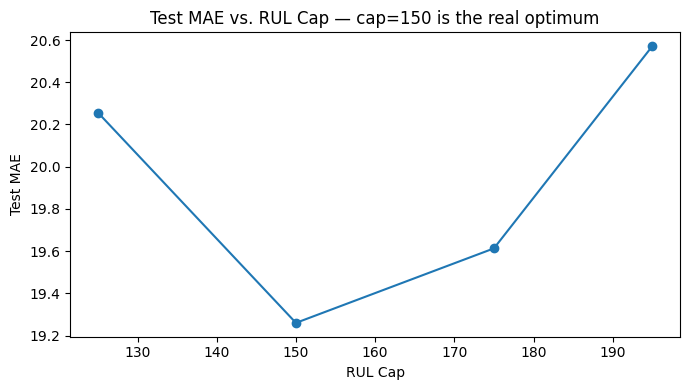

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_data = cap_results[cap_results["cap"] != "none"].copy()
plot_data["cap_num"] = plot_data["cap"].astype(int)
ax.plot(plot_data["cap_num"], plot_data["test_MAE"], marker="o")
ax.set_xlabel("RUL Cap")
ax.set_ylabel("Test MAE")
ax.set_title("Test MAE vs. RUL Cap — cap=150 is the real optimum")
plt.tight_layout()
plt.show()

**No cap was the worst option of all five** (test MAE 27.13) — 23% of training rows carry
raw RUL labels up to 542 cycles, mostly noise from the unrealistic assumption that healthy
engines degrade linearly from cycle 1. **Cap=150 won outright** (test MAE 19.26, beating
the original 125's 20.26 on both MAE and R²) and was promoted to the project's canonical
cap — that's the model already loaded and evaluated in Section 12 above.

<a id='14'></a>
## 14. Fair CatBoost vs. LSTM Comparison

The LSTM in Section 11 was retrained on the corrected `cap=150` labels and evaluated with
the *exact same* official-test-set protocol as CatBoost — same 237 evaluable engines (11 of
248 test engines have fewer than the 30 cycles an LSTM window needs, and are excluded from
both models' comparison numbers for a fair count). This is the first genuinely fair
comparison between the two model families in the project.

In [ ]:
fair_comparison = pd.read_csv(REPORTS_DIR / "sprint15_fair_comparison.csv")
fair_comparison

,Model,n_engines,MAE,RMSE,R2,MAPE
0,CatBoost (cap=150),237,19.015495,25.629797,0.768241,30.054137
1,LSTM raw (cap=150),237,22.527317,30.350273,0.675009,37.447811


CatBoost wins decisively (MAE 19.02 vs. 22.53) — but the gap is smaller than an earlier,
*unfair* comparison suggested (mismatched cap and no test-set evaluation for the LSTM at the
time made it look far worse than it actually is). One genuine surprise: the **LSTM's
validation-to-test generalization gap was much smaller than CatBoost's** (1.6% vs. 7.6%) —
CatBoost is more accurate, but its validation score was a more optimistic preview of test
performance than the LSTM's was.

<a id='15'></a>
## 15. Where the Project Stands

**Current canonical model**: CatBoost, 109 selected features, Optuna-tuned hyperparameters,
trained on `cap=150` labels — `artifacts/models/best_model.pkl`.

In [ ]:
summary = pd.DataFrame([
    {"Stage": "Validation (internal, cap=150)", "MAE": 17.666, "RMSE": 24.826, "R2": 0.755},
    {"Stage": "Test (official, unseen engines)", "MAE": 19.260, "RMSE": 25.716, "R2": 0.778},
])
summary

,Stage,MAE,RMSE,R2
0,"Validation (internal, cap=150)",17.666,24.826,0.755
1,"Test (official, unseen engines)",19.260,25.716,0.778


**The story in one line per stage:**
1. Ingested and validated three official NASA files, kept the test set untouched from day one.
2. Explored the data, generated a capped RUL target, engineered 151 features.
3. Split by engine (never by row) to avoid leakage, scaled features.
4. Trained a CatBoost baseline, inspected its feature importance.
5. Ran 8 real experiments to freeze the best feature subset (109 features).
6. Ran a real Optuna search to tune hyperparameters.
7. Built an LSTM baseline, discovered the CatBoost-tuned features were actively hurting it,
   and fixed that with a raw-feature-only input.
8. Evaluated on the real official test set for the first time — found a real
   validation-to-test gap and traced it to the RUL cap.
9. Tested 5 cap strategies experimentally, found cap=150 measurably better than the
   original 125, and promoted it to canonical.
10. Built the first genuinely fair CatBoost-vs-LSTM comparison on the same test protocol.

**What's next** (not covered in this notebook): a GRU baseline using the same validated
protocol, and eventually a full three-way model comparison and final selection.